# Data cleaning visualization

This notebook documents what was pulled from VDJdb, IEDB, and McPAS-TCR, how each dataset was cleaned, what remained after each step, and what the final pooled TRB dataset looks like.

## Final outputs

- `processed/vdjdb_trb_clean.csv`
- `processed/iedb_trb_clean.csv`
- `processed/mcpas_trb_clean.csv`
- `processed/combined_trb_clean.csv`

All cleaned outputs use the same standardized columns:

- `cdr3`
- `tcr_chain`
- `v_gene`
- `j_gene`
- `peptide`
- `mhc_a`
- `mhc_b`
- `mhc_class`
- `source`

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW_VDJDB = ROOT / "vdjdb_csv" / "vdjdb.csv"
RAW_IEDB = ROOT / "iedb_data" / "tcr_full_v3.csv"
RAW_MCPAS = ROOT / "mcpas_data" / "McPAS-TCR.csv"
VDJDB_CLEAN = ROOT / "processed" / "vdjdb_trb_clean.csv"
IEDB_CLEAN = ROOT / "processed" / "iedb_trb_clean.csv"
MCPAS_CLEAN = ROOT / "processed" / "mcpas_trb_clean.csv"
COMBINED_CLEAN = ROOT / "processed" / "combined_trb_clean.csv"
FIG_DIR = ROOT / "processed" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ROOT

WindowsPath('C:/Users/ChemEGrad2025/Desktop/PepTCR/tcr_peptide_interactions')

In [10]:
vdj_raw = pd.read_csv(RAW_VDJDB, low_memory=False)
iedb_raw = pd.read_csv(RAW_IEDB, header=[0, 1], low_memory=False)
mcpas_raw = pd.read_csv(RAW_MCPAS, na_values=["NA"], keep_default_na=True, low_memory=False, encoding="cp1252")
vdj_clean = pd.read_csv(VDJDB_CLEAN, low_memory=False)
iedb_clean = pd.read_csv(IEDB_CLEAN, low_memory=False)
mcpas_clean = pd.read_csv(MCPAS_CLEAN, low_memory=False)
combined_clean = pd.read_csv(COMBINED_CLEAN, low_memory=False)

print("vdj_raw", vdj_raw.shape)
print("iedb_raw", iedb_raw.shape)
print("mcpas_raw", mcpas_raw.shape)
print("vdj_clean", vdj_clean.shape)
print("iedb_clean", iedb_clean.shape)
print("mcpas_clean", mcpas_clean.shape)
print("combined_clean", combined_clean.shape)

vdj_raw (226494, 23)
iedb_raw (226280, 73)
mcpas_raw (20227, 28)
vdj_clean (83644, 9)
iedb_clean (144443, 9)
mcpas_clean (7801, 9)
combined_clean (235888, 9)


## Source columns pulled from each database

### Table: VDJdb raw-to-standardized column map

In [11]:
vdjdb_column_map = pd.DataFrame(
    [
        ["cdr3", "cdr3", "TCR beta CDR3 amino-acid sequence"],
        ["gene", "tcr_chain", "TCR chain label, filtered to TRB"],
        ["v.segm", "v_gene", "V gene"],
        ["j.segm", "j_gene", "J gene"],
        ["antigen.epitope", "peptide", "Epitope / peptide sequence"],
        ["mhc.a", "mhc_a", "Primary HLA / MHC field"],
        ["mhc.b", "mhc_b", "Secondary MHC-associated field, often B2M"],
        ["mhc.class", "mhc_class", "MHC class label"],
        ["species", "filter only", "Used to keep HomoSapiens only"],
    ],
    columns=["VDJdb raw column", "Standardized column", "Use"],
)
vdjdb_column_map

,VDJdb raw column,Standardized column,Use
0,cdr3,cdr3,TCR beta CDR3 amino-acid sequence
1,gene,tcr_chain,"TCR chain label, filtered to TRB"
2,v.segm,v_gene,V gene
3,j.segm,j_gene,J gene
4,antigen.epitope,peptide,Epitope / peptide sequence
5,mhc.a,mhc_a,Primary HLA / MHC field
6,mhc.b,mhc_b,"Secondary MHC-associated field, often B2M"
7,mhc.class,mhc_class,MHC class label
8,species,filter only,Used to keep HomoSapiens only


### Table: Head of raw VDJdb data

In [12]:
vdj_raw.head()

,complex.id,gene,cdr3,v.segm,j.segm,species,mhc.a,mhc.b,mhc.class,antigen.epitope,antigen.gene,antigen.species,reference.id,vdjdb.score,TCR_hash,method,meta,cdr3fix,web.method,web.method.seq,web.cdr3fix.nc,web.cdr3fix.unmp,vdjdb.pgen.score
0,0,TRB,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,M,InfluenzaA,PMID:28629751,3,NaN,"{""identification"": ""tetramer-sort "", ""frequenc...","{""study.id"": """", ""cell.subset"": ""CD8+"", ""subje...","{""cdr3"": ""CASSIVGGNEQFF"", ""cdr3_old"": ""CASSIVG...",sort,amplicon,no,no,2
1,0,TRB,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,M,InfluenzaA,PMID:28629751,3,NaN,"{""identification"": ""tetramer-sort "", ""frequenc...","{""study.id"": """", ""cell.subset"": ""CD8+"", ""subje...","{""cdr3"": ""CASSMRSTGELFF"", ""cdr3_old"": ""CASSMRS...",sort,amplicon,no,no,2
2,0,TRB,CASSIRSAWAQYF,TRBV19*01,TRBJ2-3*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,M,InfluenzaA,PMID:28629751,2,NaN,"{""identification"": ""tetramer-sort "", ""frequenc...","{""study.id"": """", ""cell.subset"": ""CD8+"", ""subje...","{""cdr3"": ""CASSIRSAWAQYF"", ""cdr3_old"": ""CASSIRS...",sort,amplicon,no,no,2
3,0,TRB,CASSQRSTGELFF,TRBV19*01,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,M,InfluenzaA,PMID:28629751,2,NaN,"{""identification"": ""tetramer-sort "", ""frequenc...","{""study.id"": """", ""cell.subset"": ""CD8+"", ""subje...","{""cdr3"": ""CASSQRSTGELFF"", ""cdr3_old"": ""CASSQRS...",sort,amplicon,no,no,3
4,0,TRB,CASSIRSSYEQYF,TRBV19*01,TRBJ2-7*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,M,InfluenzaA,PMID:28629751,3,NaN,"{""identification"": ""tetramer-sort "", ""frequenc...","{""study.id"": """", ""cell.subset"": ""CD8+"", ""subje...","{""cdr3"": ""CASSIRSSYEQYF"", ""cdr3_old"": ""CASSIRS...",sort,amplicon,no,no,3


### Table: IEDB raw-to-standardized column map

In [13]:
iedb_column_map = pd.DataFrame(
    [
        ["('Chain 2', 'CDR3 Curated') or ('Chain 2', 'CDR3 Calculated')", "cdr3", "TCR beta CDR3 amino-acid sequence"],
        ["constant TRB", "tcr_chain", "Chain label assigned during standardization"],
        ["('Chain 2', 'Curated V Gene') or ('Chain 2', 'Calculated V Gene')", "v_gene", "V gene"],
        ["('Chain 2', 'Curated J Gene') or ('Chain 2', 'Calculated J Gene')", "j_gene", "J gene"],
        ["('Epitope', 'Name')", "peptide", "Epitope / peptide sequence"],
        ["('Assay', 'MHC Allele Names')", "mhc_a", "Main MHC allele field"],
        ["not available as a separate comparable field", "mhc_b", "Left blank in IEDB cleaned output"],
        ["inferred from ('Assay', 'MHC Allele Names')", "mhc_class", "Inferred MHCI vs MHCII"],
        ["('Chain 2', 'Type') and ('Chain 2', 'Organism IRI')", "filter only", "Used to keep human beta-chain TCR rows"],
    ],
    columns=["IEDB raw column(s)", "Standardized column", "Use"],
)
iedb_column_map

,IEDB raw column(s),Standardized column,Use
0,"('Chain 2', 'CDR3 Curated') or ('Chain 2', 'CD...",cdr3,TCR beta CDR3 amino-acid sequence
1,constant TRB,tcr_chain,Chain label assigned during standardization
2,"('Chain 2', 'Curated V Gene') or ('Chain 2', '...",v_gene,V gene
3,"('Chain 2', 'Curated J Gene') or ('Chain 2', '...",j_gene,J gene
4,"('Epitope', 'Name')",peptide,Epitope / peptide sequence
5,"('Assay', 'MHC Allele Names')",mhc_a,Main MHC allele field
6,not available as a separate comparable field,mhc_b,Left blank in IEDB cleaned output
7,"inferred from ('Assay', 'MHC Allele Names')",mhc_class,Inferred MHCI vs MHCII
8,"('Chain 2', 'Type') and ('Chain 2', 'Organism ...",filter only,Used to keep human beta-chain TCR rows


### Table: Head of raw IEDB data

In [14]:
iedb_raw.head()

Receptor                                  \
                            Group IRI IEDB Receptor ID Reference Name   
0    https://www.iedb.org/receptor/47               57         KK50.4   
1    https://www.iedb.org/receptor/47               57         KK50.4   
2  https://www.iedb.org/receptor/1412               58           LC13   
3  https://www.iedb.org/receptor/1412               58           LC13   
4  https://www.iedb.org/receptor/1412               58           LC13   

                                           Reference  \
        Type                                IEDB IRI   
0  alphabeta  https://www.iedb.org/reference/1004539   
1  alphabeta  https://www.iedb.org/reference/1004539   
2  alphabeta  https://www.iedb.org/reference/1004580   
3  alphabeta  https://www.iedb.org/reference/1004580   
4  alphabeta  https://www.iedb.org/reference/1017865   

                               Epitope             \
                              IEDB IRI       Name   
0   https://www.iedb.org/epitope/69921  VMAPRTLIL   
1   https://www.iedb.org/epitope/69921  VMAPRTLIL   
2   https://www.iedb.org/epitope/16878  FLRGRAYGL   
3  https://www.iedb.org/epitope/144889  FLRGRFYGL   
4  https://www.iedb.org/epitope/142137  EEYLQAFTY   

                                                      \
                                     Source Molecule   
0  HLA class I histocompatibility antigen, Cw-3 a...   
1  HLA class I histocompatibility antigen, Cw-3 a...   
2                             nuclear antigen EBNA-3   
3                                                NaN   
4         ATP-binding cassette sub-family D member 3   

                                              Assay  \
                            Source Organism    Type   
0                      Homo sapiens (human)  T cell   
1                      Homo sapiens (human)  T cell   
2  Human herpesvirus 4 (Epstein Barr virus)  T cell   
3                                       NaN  T cell   
4                      Homo sapiens (human)  T cell   

                                                       Chain 1  \
                    IEDB IDs          MHC Allele Names    Type   
0           1548960, 1583178  HLA-E*01:01, HLA-E*01:03   alpha   
1                    1583178               HLA-E*01:03   alpha   
2  1814845, 1814846, 1814847                    HLA-B8   alpha   
3                    1831737                    HLA-B8   alpha   
4                    1778942               HLA-B*44:02   alpha   

                                                                      \
                                    Organism IRI Nucleotide Sequence   
0  http://purl.obolibrary.org/obo/NCBITaxon_9606                 NaN   
1  http://purl.obolibrary.org/obo/NCBITaxon_9606                 NaN   
2  http://purl.obolibrary.org/obo/NCBITaxon_9606                 NaN   
3  http://purl.obolibrary.org/obo/NCBITaxon_9606                 NaN   
4  http://purl.obolibrary.org/obo/NCBITaxon_9606                 NaN   

                                                                     \
  Curated V Gene Calculated V Gene Curated D Gene Calculated D Gene   
0    TRAV26-1*01       TRAV26-1*01            NaN               NaN   
1            NaN       TRAV26-1*01            NaN               NaN   
2            NaN       TRAV26-2*01            NaN               NaN   
3            NaN       TRAV26-2*01            NaN               NaN   
4            NaN               NaN            NaN               NaN   

                                    \
  Curated J Gene Calculated J Gene   
0      TRAJ37*01         TRAJ37*01   
1            NaN               NaN   
2            NaN               NaN   
3            NaN               NaN   
4            NaN               NaN   

                                                      \
                                    Protein Sequence   
0  KTTQPPSMDCAEGRAANLPCNHSTISGNEYVYWYRQIHSQGPQYII...   
1  KTTQPPSMDCAEGRAANLPCNHSTISGNEYVYWYRQIHSQGPQYII...   
2  KTTQPNSMESNEE

### Table: McPAS raw-to-standardized column map

In [15]:
mcpas_column_map = pd.DataFrame(
    [
        ["CDR3.beta.aa", "cdr3", "TCR beta CDR3 amino-acid sequence"],
        ["constant TRB", "tcr_chain", "Chain label assigned during standardization"],
        ["TRBV", "v_gene", "V gene"],
        ["TRBJ", "j_gene", "J gene"],
        ["Epitope.peptide", "peptide", "Epitope / peptide sequence"],
        ["MHC", "mhc_a", "Main MHC allele field"],
        ["not available as a separate comparable field", "mhc_b", "Left blank in McPAS cleaned output"],
        ["inferred from MHC", "mhc_class", "Inferred MHCI vs MHCII"],
        ["Species", "filter only", "Used to keep Human only"],
    ],
    columns=["McPAS raw column", "Standardized column", "Use"],
)
mcpas_column_map

,McPAS raw column,Standardized column,Use
0,CDR3.beta.aa,cdr3,TCR beta CDR3 amino-acid sequence
1,constant TRB,tcr_chain,Chain label assigned during standardization
2,TRBV,v_gene,V gene
3,TRBJ,j_gene,J gene
4,Epitope.peptide,peptide,Epitope / peptide sequence
5,MHC,mhc_a,Main MHC allele field
6,not available as a separate comparable field,mhc_b,Left blank in McPAS cleaned output
7,inferred from MHC,mhc_class,Inferred MHCI vs MHCII
8,Species,filter only,Used to keep Human only


### Table: Head of raw McPAS data

In [16]:
mcpas_raw.head()

,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,NGS,Antigen.protein,Protein.ID,Epitope.peptide,Epitope.ID,MHC,Tissue,T.Cell.Type,T.cell.characteristics,CDR3.alpha.nt,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
0,NaN,CASSDAGANTEVF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,Pre-glycoprotein polyprotein GP complex,P09991,IKAVYNFATCG,26751,H-2db,NaN,CD8,NaN,NaN,NaN,NaN,TRBV8-01,NaN,TRBJ1-1,No,NaN,P14,1716213,NaN
1,NaN,CASSDAGAYAEQF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,Pre-glycoprotein polyprotein GP complex,P09991,IKAVYNFATCG,26751,H-2db,NaN,CD8,NaN,NaN,NaN,NaN,TRBV8-01,NaN,TRBJ2-1,No,NaN,P14,1716213,NaN
2,NaN,CASSDAGGAAEVF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,Pre-glycoprotein polyprotein GP complex,P09991,IKAVYNFATCG,26751,H-2db,NaN,CD8,NaN,NaN,NaN,NaN,TRBV8-03,NaN,TRBJ1-1,No,NaN,P14,1716213,NaN
3,NaN,CASSDAGHSPLYF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,Pre-glycoprotein polyprotein GP complex,P09991,IKAVYNFATCG,26751,H-2db,NaN,CD8,NaN,NaN,NaN,NaN,TRBV8-01,NaN,TRBJ1-6,No,NaN,P14,1716213,NaN
4,NaN,CASSDAWGGAEQYF,Mouse,Pathogens,Lymphocytic choriomeningitis virus (LCMV),D008217,NaN,2.1,No,Pre-glycoprotein polyprotein GP complex,P09991,IKAVYNFATCG,26751,H-2db,NaN,CD8,NaN,NaN,NaN,NaN,TRBV8-03,NaN,TRBJ2-6,No,NaN,P14,1716213,NaN


## Cleaning steps

### Table: VDJdb cleaning steps

In [17]:
vdj_steps = pd.DataFrame(
    [
        ["1", "Keep only HomoSapiens rows", "species == 'HomoSapiens'"],
        ["2", "Keep only TRB rows", "gene == 'TRB'"],
        ["3", "Require non-empty fields", "cdr3, v.segm, j.segm, mhc.a, mhc.b, mhc.class, antigen.epitope"],
        ["4", "Remove wildcard sequences", "drop rows where cdr3 or antigen.epitope contains X, * or ?"],
        ["5", "Remove multi-peptide TCRs", "drop TCR identities mapping to more than one peptide"],
        ["6", "Drop duplicate rows", "deduplicate on the standardized biological fields"],
    ],
    columns=["Step", "Operation", "Rule"],
)
vdj_steps

,Step,Operation,Rule
0,1,Keep only HomoSapiens rows,species == 'HomoSapiens'
1,2,Keep only TRB rows,gene == 'TRB'
2,3,Require non-empty fields,"cdr3, v.segm, j.segm, mhc.a, mhc.b, mhc.class,..."
3,4,Remove wildcard sequences,drop rows where cdr3 or antigen.epitope contai...
4,5,Remove multi-peptide TCRs,drop TCR identities mapping to more than one p...
5,6,Drop duplicate rows,deduplicate on the standardized biological fields


### Table: IEDB cleaning steps

In [18]:
iedb_steps = pd.DataFrame(
    [
        ["1", "Keep only beta-chain rows", "('Chain 2', 'Type') == 'beta'"],
        ["2", "Keep only human rows", "('Chain 2', 'Organism IRI') contains NCBITaxon_9606"],
        ["3", "Standardize columns", "use curated CDR3/V/J when present, otherwise calculated values"],
        ["4", "Require non-empty fields", "cdr3, v_gene, j_gene, peptide, mhc_a, mhc_class"],
        ["5", "Remove wildcard sequences", "drop rows where cdr3 or peptide contains X, * or ?"],
        ["6", "Remove multi-peptide TCRs", "drop TCR identities mapping to more than one peptide"],
        ["7", "Drop duplicate rows", "deduplicate on the standardized biological fields"],
    ],
    columns=["Step", "Operation", "Rule"],
)
iedb_steps

,Step,Operation,Rule
0,1,Keep only beta-chain rows,"('Chain 2', 'Type') == 'beta'"
1,2,Keep only human rows,"('Chain 2', 'Organism IRI') contains NCBITaxon..."
2,3,Standardize columns,"use curated CDR3/V/J when present, otherwise c..."
3,4,Require non-empty fields,"cdr3, v_gene, j_gene, peptide, mhc_a, mhc_class"
4,5,Remove wildcard sequences,"drop rows where cdr3 or peptide contains X, * ..."
5,6,Remove multi-peptide TCRs,drop TCR identities mapping to more than one p...
6,7,Drop duplicate rows,deduplicate on the standardized biological fields


### Table: McPAS cleaning steps

In [19]:
mcpas_steps = pd.DataFrame(
    [
        ["1", "Keep only Human rows", "Species == 'Human'"],
        ["2", "Standardize columns", "use CDR3.beta.aa, TRBV, TRBJ, Epitope.peptide, and MHC"],
        ["3", "Infer mhc_class", "infer MHCI vs MHCII from the MHC field"],
        ["4", "Require non-empty fields", "cdr3, v_gene, j_gene, peptide, mhc_a, mhc_class"],
        ["5", "Remove wildcard sequences", "drop rows where cdr3 or peptide contains X, * or ?"],
        ["6", "Remove multi-peptide TCRs", "drop TCR identities mapping to more than one peptide"],
        ["7", "Drop duplicate rows", "deduplicate on the standardized biological fields"],
    ],
    columns=["Step", "Operation", "Rule"],
)
mcpas_steps

,Step,Operation,Rule
0,1,Keep only Human rows,Species == 'Human'
1,2,Standardize columns,"use CDR3.beta.aa, TRBV, TRBJ, Epitope.peptide,..."
2,3,Infer mhc_class,infer MHCI vs MHCII from the MHC field
3,4,Require non-empty fields,"cdr3, v_gene, j_gene, peptide, mhc_a, mhc_class"
4,5,Remove wildcard sequences,"drop rows where cdr3 or peptide contains X, * ..."
5,6,Remove multi-peptide TCRs,drop TCR identities mapping to more than one p...
6,7,Drop duplicate rows,deduplicate on the standardized biological fields


## VDJdb retention summary

### Table: VDJdb rows retained and removed at each step

In [20]:
vdj_counts = pd.DataFrame(
    [
        ["Loaded raw VDJdb rows", 226494, 0],
        ["After HomoSapiens filter", 206106, 20388],
        ["After TRB filter", 113281, 92825],
        ["After required-field filter", 113281, 0],
        ["After wildcard filter", 113281, 0],
        ["After multi-peptide filter", 101798, 11483],
        ["After de-duplication", 83644, 18154],
    ],
    columns=["Stage", "Rows remaining", "Rows removed at step"],
)
vdj_counts

,Stage,Rows remaining,Rows removed at step
0,Loaded raw VDJdb rows,226494,0
1,After HomoSapiens filter,206106,20388
2,After TRB filter,113281,92825
3,After required-field filter,113281,0
4,After wildcard filter,113281,0
5,After multi-peptide filter,101798,11483
6,After de-duplication,83644,18154


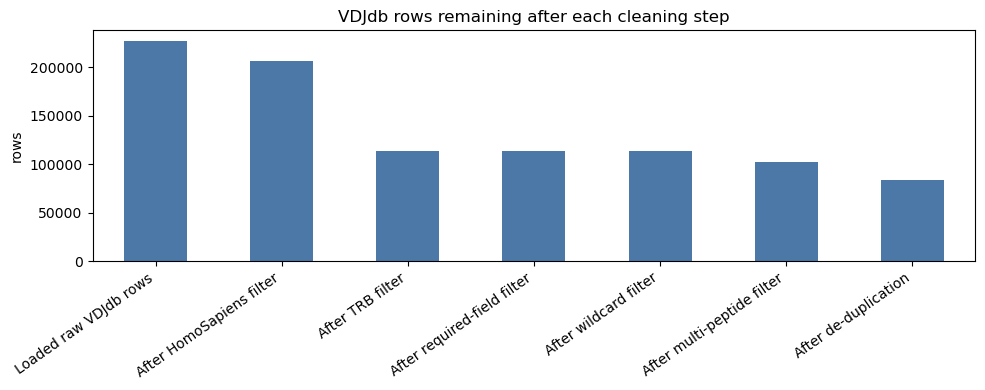

In [21]:
ax = vdj_counts.set_index("Stage")["Rows remaining"].plot(kind="bar", figsize=(10, 4), color="#4C78A8", title="VDJdb rows remaining after each cleaning step")
ax.set_ylabel("rows")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "vdjdb_cleaning_steps.png", dpi=200, bbox_inches="tight")
plt.show()

## IEDB retention summary

### Table: IEDB rows retained and removed at each step

In [22]:
iedb_counts = pd.DataFrame(
    [
        ["Loaded raw IEDB rows", 226280, 0],
        ["After beta-chain filter", 195028, 31252],
        ["After human filter", 187488, 7540],
        ["After required-field filter", 160630, 26858],
        ["After wildcard filter", 160626, 4],
        ["After multi-peptide filter", 146819, 13807],
        ["After de-duplication", 144443, 2376],
    ],
    columns=["Stage", "Rows remaining", "Rows removed at step"],
)
iedb_counts

,Stage,Rows remaining,Rows removed at step
0,Loaded raw IEDB rows,226280,0
1,After beta-chain filter,195028,31252
2,After human filter,187488,7540
3,After required-field filter,160630,26858
4,After wildcard filter,160626,4
5,After multi-peptide filter,146819,13807
6,After de-duplication,144443,2376


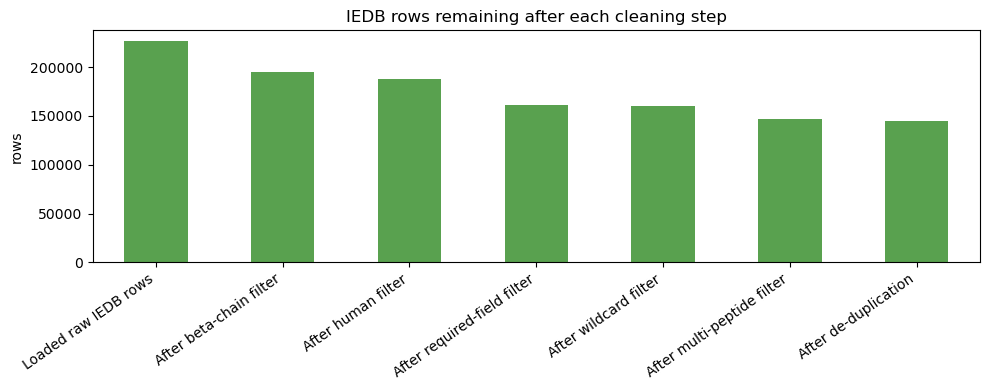

In [23]:
ax = iedb_counts.set_index("Stage")["Rows remaining"].plot(kind="bar", figsize=(10, 4), color="#59A14F", title="IEDB rows remaining after each cleaning step")
ax.set_ylabel("rows")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "iedb_cleaning_steps.png", dpi=200, bbox_inches="tight")
plt.show()

## McPAS retention summary

### Table: McPAS rows retained and removed at each step

In [24]:
mcpas_counts = pd.DataFrame(
    [
        ["Loaded raw McPAS rows", 40731, 0],
        ["After Human filter", 36474, 4257],
        ["After required-field filter", 9370, 27104],
        ["After wildcard filter", 9361, 9],
        ["After multi-peptide filter", 8764, 597],
        ["After de-duplication", 8268, 496],
    ],
    columns=["Stage", "Rows remaining", "Rows removed at step"],
)
mcpas_counts

,Stage,Rows remaining,Rows removed at step
0,Loaded raw McPAS rows,40731,0
1,After Human filter,36474,4257
2,After required-field filter,9370,27104
3,After wildcard filter,9361,9
4,After multi-peptide filter,8764,597
5,After de-duplication,8268,496


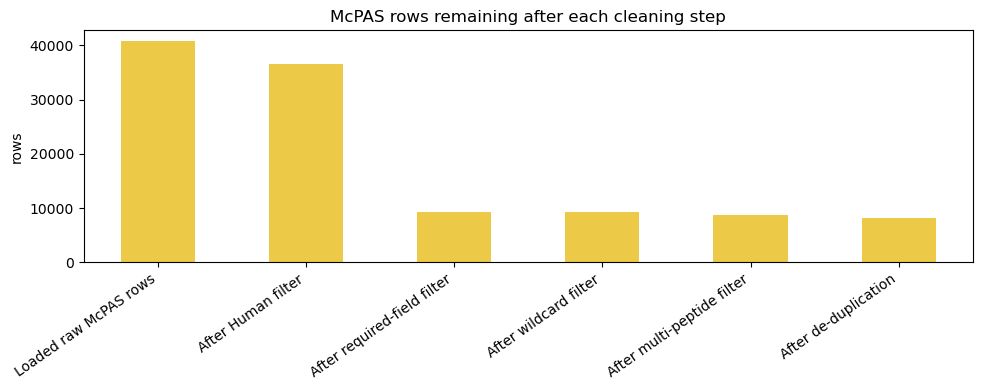

In [25]:
ax = mcpas_counts.set_index("Stage")["Rows remaining"].plot(kind="bar", figsize=(10, 4), color="#EDC948", title="McPAS rows remaining after each cleaning step")
ax.set_ylabel("rows")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "mcpas_cleaning_steps.png", dpi=200, bbox_inches="tight")
plt.show()

## What remained after pooling

### Table: Pooled dataset row counts

In [26]:
pooled_summary = pd.DataFrame(
    [
        ["VDJdb cleaned rows", 83644],
        ["IEDB cleaned rows", 144443],
        ["McPAS cleaned rows", 8268],
        ["Sum before pooling", 236355],
        ["Exact cross-source duplicates removed during pooling", 0],
        ["Final combined rows", 236355],
    ],
    columns=["Quantity", "Value"],
)
pooled_summary

,Quantity,Value
0,VDJdb cleaned rows,83644
1,IEDB cleaned rows,144443
2,McPAS cleaned rows,8268
3,Sum before pooling,236355
4,Exact cross-source duplicates removed during p...,0
5,Final combined rows,236355


### Table: Final combined rows by source

In [27]:
combined_clean["source"].value_counts().rename_axis("source").reset_index(name="rows")

,source,rows
0,IEDB,144443
1,VDJdb,83644
2,McPAS,7801


## What the combined dataset looks like

### Table: Combined dataset summary statistics

In [28]:
combined_summary = pd.Series(
    {
        "rows": len(combined_clean),
        "unique CDR3s": combined_clean["cdr3"].nunique(),
        "unique peptides": combined_clean["peptide"].nunique(),
        "unique V genes": combined_clean["v_gene"].nunique(),
        "unique J genes": combined_clean["j_gene"].nunique(),
        "unique mhc_a": combined_clean["mhc_a"].nunique(),
        "rows from VDJdb": int((combined_clean["source"] == "VDJdb").sum()),
        "rows from IEDB": int((combined_clean["source"] == "IEDB").sum()),
        "rows from McPAS": int((combined_clean["source"] == "McPAS").sum()),
    }
)
combined_summary

rows               235888
unique CDR3s       204182
unique peptides      1760
unique V genes        589
unique J genes        148
unique mhc_a          235
rows from VDJdb     83644
rows from IEDB     144443
rows from McPAS      7801
dtype: int64

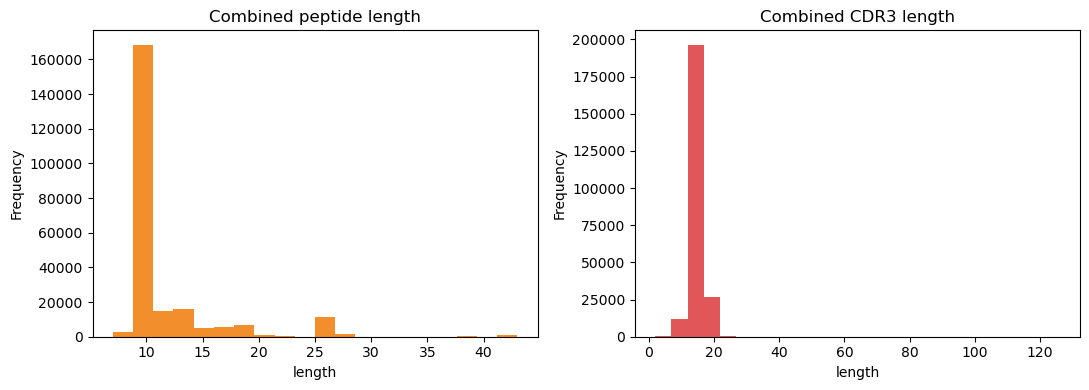

In [29]:
combined_clean = combined_clean.assign(
    peptide_len=combined_clean["peptide"].astype(str).str.len(),
    cdr3_len=combined_clean["cdr3"].astype(str).str.len(),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
combined_clean["peptide_len"].plot(kind="hist", bins=20, ax=axes[0], color="#F28E2B", title="Combined peptide length")
combined_clean["cdr3_len"].plot(kind="hist", bins=25, ax=axes[1], color="#E15759", title="Combined CDR3 length")
axes[0].set_xlabel("length")
axes[1].set_xlabel("length")
plt.tight_layout()
plt.savefig(FIG_DIR / "combined_length_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

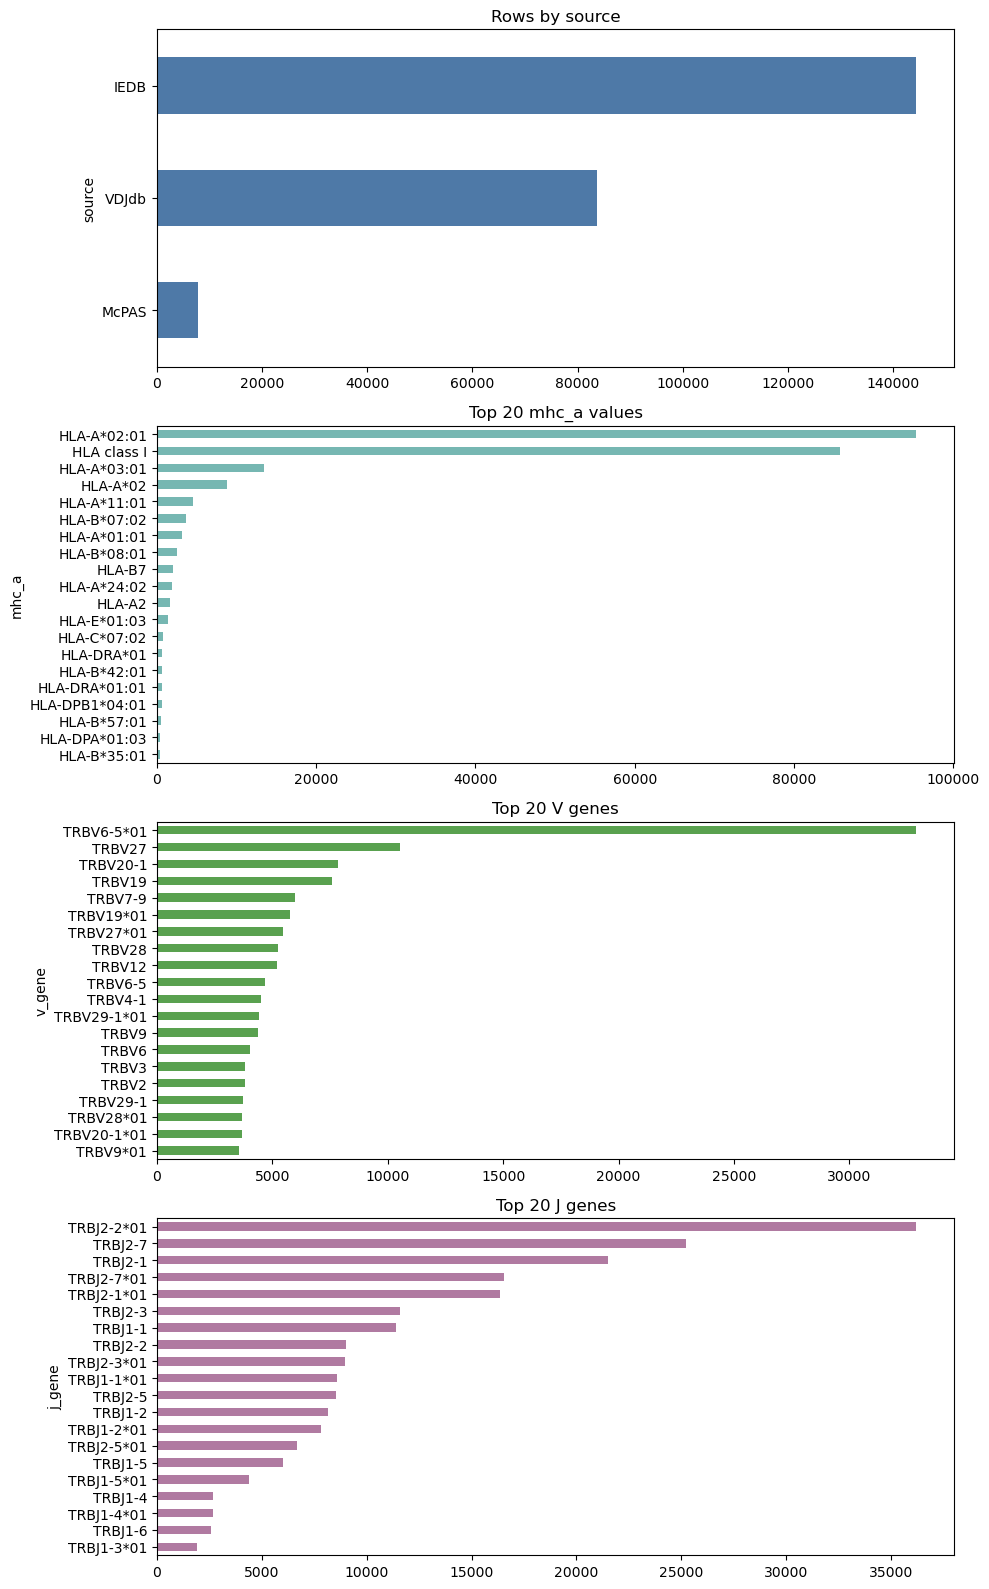

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(10, 16))
combined_clean["source"].value_counts().sort_values().plot(kind="barh", ax=axes[0], color="#4E79A7", title="Rows by source")
combined_clean["mhc_a"].value_counts().head(20).sort_values().plot(kind="barh", ax=axes[1], color="#76B7B2", title="Top 20 mhc_a values")
combined_clean["v_gene"].value_counts().head(20).sort_values().plot(kind="barh", ax=axes[2], color="#59A14F", title="Top 20 V genes")
combined_clean["j_gene"].value_counts().head(20).sort_values().plot(kind="barh", ax=axes[3], color="#B07AA1", title="Top 20 J genes")
plt.tight_layout()
plt.savefig(FIG_DIR / "combined_top_features.png", dpi=200, bbox_inches="tight")
plt.show()

### Table: Example rows from the final combined dataset

In [31]:
combined_clean.head()

,cdr3,tcr_chain,v_gene,j_gene,peptide,mhc_a,mhc_b,mhc_class,source,peptide_len,cdr3_len
0,CASSNRAGNEQFF,TRB,TRBV19*01,TRBJ2-1*01,YVLDHLIVV,HLA-A*02:01,B2M,MHCI,VDJdb,9,13
1,CASSMRSADTQYF,TRB,TRBV19*01,TRBJ2-3*01,GILGFVFTL,HLA-A*02:01,B2M,MHCI,VDJdb,9,13
2,CASSVRASDEQYF,TRB,TRBV19*01,TRBJ2-7*01,GILGFVFTL,HLA-A*02:01,B2M,MHCI,VDJdb,9,13
3,CASSPSSVADTQYF,TRB,TRBV19*01,TRBJ2-3*01,GILGFVFTL,HLA-A*02:01,B2M,MHCI,VDJdb,9,14
4,CASSSRAAYEQYF,TRB,TRBV19*01,TRBJ2-7*01,GILGFVFTL,HLA-A*02:01,B2M,MHCI,VDJdb,9,13
